# Prototype dependence, attribution and causality — POC

Reads **only** the prototype tables in `fed_sandbox/<world_id>/<run_id>/`
(`prototype_history`, `global_prototype_history`). No latents, no sensors, no weights.
Every section runs over **all** worlds/runs found in the cache.

Four questions the PCA scatter blends together, separated here because they need
different instruments and have very different power:

| | question | module | instrument |
|---|---|---|---|
| 1 | are same-regime districts co-located? | §A | exact label-permutation test on the 5×5 distance matrix |
| 2 | did some client change? | §B | two-segment change point on displacement magnitude |
| 3 | which client is the source? | §B | onset ordering + level shift, scored against the known drift district |
| 4 | who leads whom? | §C–§E | lead-lag, Granger, out-of-sample predictive transfer |

**Three confounds neutralized before any number is read.** *Basis non-identifiability* —
the encoder is defined only up to rotation and the sandbox plots use a per-round PCA
fit, so raw coordinates are not comparable across rounds; all statistics here are
relational or within-round (§3 measures how much rotation is actually present).
*Common seasonal driver* — every district shares the month index and the seasonal
multiplier, so two independent clients are trivially mutually causal; the common mode
is removed with a **geometric median** (robust *and* rotation-equivariant) estimated
from clients outside the pair under test. *Federated coupling* — FedAvg plus the
prototype anchor couple all clients every round; `dev_global*` representations and any
`proto_alpha=0` run in the cache bound how much of a result is protocol rather than
hydraulics.

## 1. Setup

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[1]                 # notebooks/prospection -> repo root
sys.path.insert(0, str(ROOT / "src"))
import proto_dependence as PD

SANDBOX = Path("fed_sandbox")
OUT     = Path("proto_dependence_out")
pd.set_option("display.width", 250)
pd.set_option("display.max_columns", 60)

CONFIG = dict(
    representation = "resid",       # raw | centered | resid | dev_global[_centered]
    common_mode    = "geomedian",   # geomedian | mean | median
    difference     = True,          # modules C/D/E work on first differences
    baseline_months= 6,             # fallback pre-drift window if onset is unknown
    metric         = "cosine",
    n_components   = 2,
    lags           = 2,
    max_lag        = 4,
    ridge          = 1e-2,
    train_frac     = 0.7,
    n_surrogates           = 199,
    n_surrogates_expensive = 99,
    alpha          = 0.05,
    seed           = 0,
)

# BFS hop distance from each world's epicenter. Needed only by §B's delay-structure
# test (the statistic most directly aligned with the simulator's diffusion ramp);
# every other test runs without it. Fill from gt_topology, e.g.
# HOPS = {"E_LI__LR_LC_LI_LR_LR": {"District_A": 2, ..., "District_E": 0}}
HOPS: dict = {}

## 2. Discovery — every world/run in the cache

In [2]:
runs = PD.list_fed_runs(SANDBOX, repo_root=ROOT, onset_default=None)
print(f"{len(runs)} runs across {runs.world_id.nunique()} worlds")
runs[["world_id","run_id","drift_district","drift_onset","onset_source",
      "consumption_map","n_clients","n_months","n_rounds","latent_dim","has_global"]]

373 runs across 61 worlds


,world_id,run_id,drift_district,drift_onset,onset_source,consumption_map,n_clients,n_months,n_rounds,latent_dim,has_global
0,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,30,20,60,True
1,00ac315559fc,20260829-212013_fed_u30_r20_le1_a0.0_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,30,20,60,True
2,00ac315559fc,20260829-212153_fed_u30_r20_le1_a0.2_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,30,20,60,True
3,00ac315559fc,20260829-212407_fed_u30_r20_le1_a0.2_agg2h_w84...,None,NaN,manifest+default_onset,None,5,30,20,60,True
4,00ac315559fc,20260829-212749_fed_u30_r40_le1_a0.2_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,30,40,60,True
...,...,...,...,...,...,...,...,...,...,...,...
368,local,20260830-200633_fed_u30_r20_le1_a0.0_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,24,20,60,True
369,local,20260830-200755_fed_u30_r20_le1_a0.2_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,24,20,60,True
370,local,20260830-200929_fed_u30_r20_le1_a0.2_agg2h_w84...,None,NaN,manifest+default_onset,None,5,24,20,60,True
371,local,20260830-201214_fed_u30_r40_le1_a0.2_agg2h_w24_s6,None,NaN,manifest+default_onset,None,5,24,40,60,True


In [3]:
# onset_source == "...+default_onset" means the manifest had no warmup_months and the
# baseline window fell back to CONFIG["baseline_months"] — that silently changes every
# downstream statistic, so check it rather than trusting it.
bad = runs[runs.onset_source.str.contains("default")]
print("runs with a defaulted onset:", len(bad))
print("runs missing a drift district:", runs.drift_district.isna().sum())

runs with a defaulted onset: 133
runs missing a drift district: 133


## 3. Diagnostics

`procrustes_*` is the basis rotation between consecutive rounds — the justification for
using relational statistics rather than raw coordinates. `common_mode_var_share` is how
much of the centered prototype variance is the shared seasonal driver (expect it to be
large; that is the confound §C–§E remove). `fingerprint_ratio` is between-client offset
over within-client movement — large values are why `probe_district` saturates and why
static similarity is hard to see in a PCA scatter.

In [4]:
diag = pd.concat([PD.diagnostics(PD.ProtoRun(r["path"], r["world_id"], r["run_id"],
                                             r["drift_district"], r["drift_onset"], cfg=CONFIG))
                  for _, r in runs.iterrows()], ignore_index=True)
diag[["world_id","run_id","n_months","n_rounds","latent_dim","baseline_months",
      "global_source","common_mode_var_share","procrustes_mean","fingerprint_ratio",
      "obs_per_pair"]].round(4)

,world_id,run_id,n_months,n_rounds,latent_dim,baseline_months,global_source,common_mode_var_share,procrustes_mean,fingerprint_ratio,obs_per_pair
0,00ac315559fc,20260829-211832_fed_u30_r20_le1_a0.2_agg2h_w24_s6,30,20,60,6,global_prototype_history,0.9293,0.0968,0.0920,28
1,00ac315559fc,20260829-212013_fed_u30_r20_le1_a0.0_agg2h_w24_s6,30,20,60,6,global_prototype_history,0.7571,0.0237,0.2883,28
2,00ac315559fc,20260829-212153_fed_u30_r20_le1_a0.2_agg2h_w24_s6,30,20,60,6,global_prototype_history,0.9293,0.0968,0.0920,28
3,00ac315559fc,20260829-212407_fed_u30_r20_le1_a0.2_agg2h_w84...,30,20,60,6,global_prototype_history,0.9082,0.0569,0.1227,28
4,00ac315559fc,20260829-212749_fed_u30_r40_le1_a0.2_agg2h_w24_s6,30,40,60,6,global_prototype_history,0.9688,0.0639,0.0626,28
...,...,...,...,...,...,...,...,...,...,...,...
368,local,20260830-200633_fed_u30_r20_le1_a0.0_agg2h_w24_s6,24,20,60,6,global_prototype_history,0.7766,0.0218,0.4104,22
369,local,20260830-200755_fed_u30_r20_le1_a0.2_agg2h_w24_s6,24,20,60,6,global_prototype_history,0.9060,0.0516,0.1257,22
370,local,20260830-200929_fed_u30_r20_le1_a0.2_agg2h_w84...,24,20,60,6,global_prototype_history,0.9425,0.0302,0.0767,22
371,local,20260830-201214_fed_u30_r40_le1_a0.2_agg2h_w24_s6,24,40,60,6,global_prototype_history,0.9026,0.0312,0.1197,22


## §A. Relational geometry and regime similarity

The claim being tested: pre-drift, E should sit near A and D (all `LR`), and post-drift
E should move toward C (`LI`). Statistic = mean between-regime distance − mean
within-regime distance, so **positive means same-regime districts co-locate**. The null
enumerates all distinct *partitions* of the districts into regime groups, exhaustively.

Read `p_floor` before `p_value`: at N=5 a 3/1/1 regime split yields only C(5,3)=10
distinct partitions, so this test **cannot return p < 0.10** however clean the geometry
is. Sign and magnitude carry the information; significance has to come from pooling
across runs.

In [5]:
import json
def list_worlds() -> dict[str, dict]:
    """world_id -> {client_dir, label, meta}. `world_id` is `sim_hash`, or `"local"`."""
    worlds: dict[str, dict] = {}

    local_dir = ROOT / "data" / "07_model_output" / "clients"
    if local_dir.exists():
        worlds["local"] = {"client_dir": local_dir, "label": "local (data/07_model_output)",
                           "meta": {}}

    exp_root = ROOT / "data" / "09_experiments" / "worlds"
    for mpath in sorted(exp_root.glob("*/manifest.json")):
        try:
            man = json.loads(mpath.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        if man.get("status") != "ok":
            continue
        sim_hash = man.get("sim_hash", mpath.parent.name)
        cdir = mpath.parent / "clone" / "data" / "07_model_output" / "clients"
        if not cdir.exists():
            continue
        meta = man.get("world", {})
        tag = meta.get("drift_district") or meta.get("consumption_map") or "?"
        worlds[sim_hash] = {"client_dir": cdir, "meta": meta,
                            "label": f"{sim_hash}  ·  {meta.get('variant', '?')}  ·  {tag}"}
    return worlds


WORLDS = list_worlds()
if not WORLDS:
    raise RuntimeError("no worlds found (no local data/07_model_output/clients, no experiments cache)")

df_worlds = pd.DataFrame([{"world_id": k, "label": v["label"], **v["meta"]} for k, v in WORLDS.items()]) \
    .set_index("world_id")

df_worlds['tag'] = df_worlds['drift_district'].str[-1] + '_' + df_worlds['drift_to_income'].str[0].str.upper() +  \
    df_worlds['drift_to_land_use'].str[0].str.upper() + '__' + df_worlds['consumption_map']

df_worlds.head()    

,label,anchor_scale,beta,close_fraction,consumption_map,drift_district,drift_seed_node,drift_to_income,drift_to_land_use,n_months,sim_seed,variant,tag
world_id,,,,,,,,,,,,,
local,local (data/07_model_output),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1044dfc21983,1044dfc21983 · baseline · District_C,0.05,0.35,0.5,LR_LI_LI_LC_LR,District_C,59,low,commercial,30.0,42.0,baseline,C_LC__LR_LI_LI_LC_LR
125bcc3f1cb5,125bcc3f1cb5 · baseline · District_A,0.05,0.35,0.5,LR_LC_LI_LR_LR,District_A,61,low,commercial,30.0,42.0,baseline,A_LC__LR_LC_LI_LR_LR
13da76aafb4d,13da76aafb4d · baseline · District_D,0.05,0.35,0.5,LR_LC_LI_LR_LR,District_D,2,low,industrial,30.0,42.0,baseline,D_LI__LR_LC_LI_LR_LR
19fc3635df2e,19fc3635df2e · baseline · District_E,0.05,0.35,0.5,LR_LI_LI_LC_LR,District_E,7,low,commercial,30.0,42.0,baseline,E_LC__LR_LI_LI_LC_LR


In [ ]:
# runs["drift_district"] / runs["consumption_map"] come from parse_world_id(), which only
# works when the world_id itself encodes them — true for hand-named worlds, false here
# (world_id is an opaque sim_hash). The real ground truth lives in df_worlds (built by
# list_worlds() from each world's manifest.json), so pull it in by world_id and overwrite
# the parsed columns. This fixes every module that keys off drift_district downstream —
# §B attribution, §4's full battery, §5's stress grid, and matched_pairs all consume
# `runs` directly, so one merge here is enough for all of them.
_meta = df_worlds[["consumption_map", "drift_district"]]
runs["drift_district"]  = runs["world_id"].map(_meta["drift_district"])
runs["consumption_map"] = runs["world_id"].map(_meta["consumption_map"])

n_missing = runs["drift_district"].isna().sum()
print(f"drift_district resolved for {len(runs) - n_missing}/{len(runs)} runs")
runs = runs[~runs['drift_district'].isna()]
runs = runs.reset_index(drop = True)

runs["tokens"] = runs["consumption_map"].apply(
    lambda cm: cm.split("_") if isinstance(cm, str) else None)


runs.head(10)

drift_district resolved for 240/373 runs


,world_id,run_id,path,drift_district,drift_onset,onset_source,drift_token,consumption_map,n_clients,n_months,n_rounds,latent_dim,has_global,fl_signature
0,1044dfc21983,20260830-201447_fed_u30_r20_le1_a0.2_agg2h_w24_s6,fed_sandbox\1044dfc21983\20260830-201447_fed_u...,District_C,5.0,manifest,None,LR_LI_LI_LC_LR,5,30,20,60,True,fed_u30_r20_le1_a0.2_agg2h_w24_s6
1,1044dfc21983,20260830-201629_fed_u30_r20_le1_a0.0_agg2h_w24_s6,fed_sandbox\1044dfc21983\20260830-201629_fed_u...,District_C,5.0,manifest,None,LR_LI_LI_LC_LR,5,30,20,60,True,fed_u30_r20_le1_a0.0_agg2h_w24_s6
2,1044dfc21983,20260830-201812_fed_u30_r20_le1_a0.2_agg2h_w24_s6,fed_sandbox\1044dfc21983\20260830-201812_fed_u...,District_C,5.0,manifest,None,LR_LI_LI_LC_LR,5,30,20,60,True,fed_u30_r20_le1_a0.2_agg2h_w24_s6
3,1044dfc21983,20260830-202006_fed_u30_r20_le1_a0.2_agg2h_w84...,fed_sandbox\1044dfc21983\20260830-202006_fed_u...,District_C,5.0,manifest,None,LR_LI_LI_LC_LR,5,30,20,60,True,fed_u30_r20_le1_a0.2_agg2h_w84_s12
4,1044dfc21983,20260830-202334_fed_u30_r40_le1_a0.2_agg2h_w24_s6,fed_sandbox\1044dfc21983\20260830-202334_fed_u...,District_C,5.0,manifest,None,LR_LI_LI_LC_LR,5,30,40,60,True,fed_u30_r40_le1_a0.2_agg2h_w24_s6
5,1044dfc21983,20260830-202441_fed_u8_r20_le1_a0.2_agg2h_w24_s6,fed_sandbox\1044dfc21983\20260830-202441_fed_u...,District_C,5.0,manifest,None,LR_LI_LI_LC_LR,5,30,20,16,True,fed_u8_r20_le1_a0.2_agg2h_w24_s6
6,125bcc3f1cb5,20260830-202627_fed_u30_r20_le1_a0.2_agg2h_w24_s6,fed_sandbox\125bcc3f1cb5\20260830-202627_fed_u...,District_A,5.0,manifest,None,LR_LC_LI_LR_LR,5,30,20,60,True,fed_u30_r20_le1_a0.2_agg2h_w24_s6
7,125bcc3f1cb5,20260830-202808_fed_u30_r20_le1_a0.0_agg2h_w24_s6,fed_sandbox\125bcc3f1cb5\20260830-202808_fed_u...,District_A,5.0,manifest,None,LR_LC_LI_LR_LR,5,30,20,60,True,fed_u30_r20_le1_a0.0_agg2h_w24_s6
8,125bcc3f1cb5,20260830-202950_fed_u30_r20_le1_a0.2_agg2h_w24_s6,fed_sandbox\125bcc3f1cb5\20260830-202950_fed_u...,District_A,5.0,manifest,None,LR_LC_LI_LR_LR,5,30,20,60,True,fed_u30_r20_le1_a0.2_agg2h_w24_s6
9,125bcc3f1cb5,20260830-203146_fed_u30_r20_le1_a0.2_agg2h_w84...,fed_sandbox\125bcc3f1cb5\20260830-203146_fed_u...,District_A,5.0,manifest,None,LR_LC_LI_LR_LR,5,30,20,60,True,fed_u30_r20_le1_a0.2_agg2h_w84_s12


23044627b86a | clients: ['District_A', 'District_B', 'District_C', 'District_D', 'District_E']
tokens (A..E, pre-drift): ['LR', 'LC', 'LI', 'LR', 'LR'] | drift: District_E
labels: {'District_A': 'LR', 'District_B': 'LC', 'District_C': 'LI', 'District_D': 'LR', 'District_E': 'LR'}


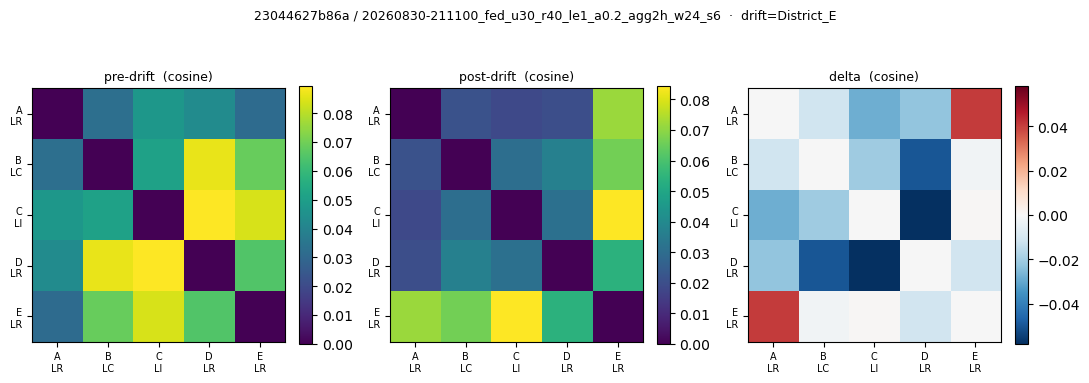

,round,grouping,test,statistic,p_value,p_floor,n_within_pairs,n_null
0,first,token,group_contrast,0.010802,0.4,0.1,3,10
1,first,sector,group_contrast,0.010802,0.4,0.1,3,10
2,first,level,group_contrast,NaN,NaN,NaN,10,0
3,last,token,group_contrast,0.019022,0.3,0.1,3,10
4,last,sector,group_contrast,0.019022,0.3,0.1,3,10
5,last,level,group_contrast,NaN,NaN,NaN,10,0


In [7]:
sel  = runs.iloc[28]
meta = df_worlds.loc[sel["world_id"]]
tokens = meta["consumption_map"].split("_")      # order: District_A..E, PRE-drift regime
onset  = None if pd.isna(sel["drift_onset"]) else int(sel["drift_onset"])

run0 = PD.ProtoRun(sel["path"], sel["world_id"], sel["run_id"],
                   drift_district=meta["drift_district"], drift_onset=onset,
                   tokens=tokens, cfg=CONFIG)
print(run0.world_id, "| clients:", run0.clients)
print("tokens (A..E, pre-drift):", tokens, "| drift:", run0.drift_district)
print("labels:", run0.labels)
PD.plot_distance_heatmaps(run0, representation="raw")

rg0 = PD.regime_geometry(run0)
display(rg0[["round","grouping","test","statistic","p_value","p_floor",
             "n_within_pairs","n_null"]])

In [8]:
# the pair table behind the claim: is the drifting district closer to its own regime
# pre-drift, and does it move toward the target regime after?
pairs0 = PD.regime_pair_table(run0)
pairs0[pairs0.district_a.eq(run0.drift_district) | pairs0.district_b.eq(run0.drift_district)]

,world_id,run_id,district_a,district_b,token_a,token_b,distance,same_token
3,23044627b86a,20260830-211100_fed_u30_r40_le1_a0.2_agg2h_w24_s6,District_A,District_E,LR,LR,0.031266,True
6,23044627b86a,20260830-211100_fed_u30_r40_le1_a0.2_agg2h_w24_s6,District_B,District_E,LC,LR,0.068409,False
8,23044627b86a,20260830-211100_fed_u30_r40_le1_a0.2_agg2h_w24_s6,District_C,District_E,LI,LR,0.083844,False
9,23044627b86a,20260830-211100_fed_u30_r40_le1_a0.2_agg2h_w24_s6,District_D,District_E,LR,LR,0.065083,True


In [9]:
INCOME_LETTER  = {"low": "L", "medium": "M", "high": "H"}
LANDUSE_LETTER = {"residential": "R", "mixed": "M", "commercial": "C", "industrial": "I"}

meta0 = df_worlds.loc[run0.world_id]
target_token = (INCOME_LETTER.get(meta0["drift_to_income"], "?")
                + LANDUSE_LETTER.get(meta0["drift_to_land_use"], "?"))
print(f"{run0.drift_district}: pre-drift token = {run0.labels[run0.drift_district]}"
      f"  ->  target token = {target_token}")

post_months = [i for i in range(len(run0.months)) if i not in run0.baseline]

pre  = PD.regime_pair_table(run0, months=run0.baseline).assign(state="pre_drift")
post = PD.regime_pair_table(run0, months=post_months).assign(state="post_drift")
pairs0 = pd.concat([pre, post], ignore_index=True)

involved = pairs0[pairs0.district_a.eq(run0.drift_district) | pairs0.district_b.eq(run0.drift_district)]
involved = involved.assign(
    other=lambda d: np.where(d.district_a.eq(run0.drift_district), d.district_b, d.district_a),
    other_token=lambda d: np.where(d.district_a.eq(run0.drift_district), d.token_b, d.token_a),
    matches_target=lambda d: d.other_token.eq(target_token))

involved.pivot_table(index=["other", "other_token", "matches_target"],
                     columns="state", values="distance")

District_E: pre-drift token = LR  ->  target token = LI


,,state,post_drift,pre_drift
other,other_token,matches_target,,
District_A,LR,False,0.071789,0.031266
District_B,LC,False,0.066532,0.068409
District_C,LI,True,0.084327,0.083844
District_D,LR,False,0.054184,0.065083


## §B. Onset ordering and drift attribution

Per client, the displacement magnitude from its own pre-drift baseline (common mode
removed), then an exhaustive single change-point fit → onset `tau` and level shift
`delta`. Two attribution estimators:

* `argmax_delta` — who moved most (magnitude of response)
* `argmin_tau` — who moved first (timing; this is the one that tracks the BFS delay)

Both are scored against the world's known drift district, so `rank_of_truth` and
`p_exact = rank / n_clients` are available per run with no extra simulation.

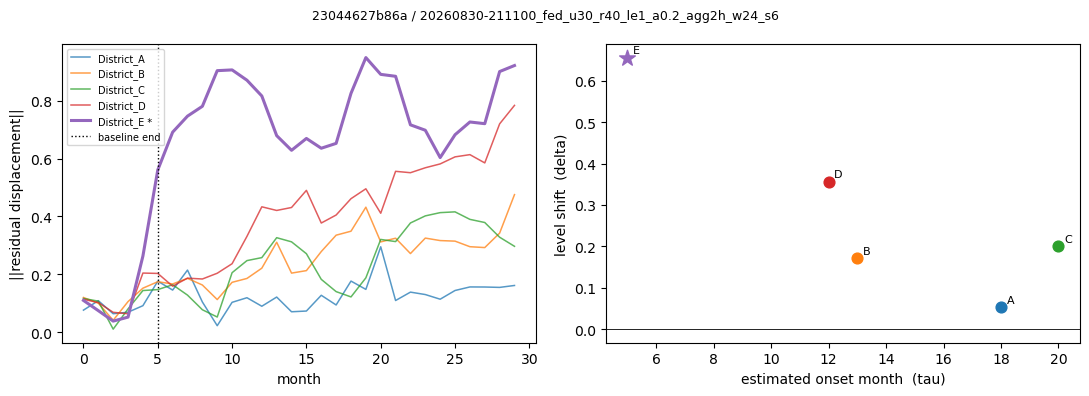

,client,tau_month,delta,r2,p_value,is_epicenter
0,District_A,18,0.053140,0.258967,0.062,False
1,District_B,13,0.171257,0.691156,0.001,False
2,District_C,20,0.199825,0.629233,0.001,False
3,District_D,12,0.356351,0.767103,0.001,False
4,District_E,5,0.655861,0.835388,0.002,True


,estimator,guess,truth,hit,rank_of_truth,p_exact,order
0,argmax_delta,District_E,District_E,True,1,0.2,District_E|District_D|District_C|District_B|Di...
1,argmin_tau,District_E,District_E,True,1,0.2,District_E|District_D|District_B|District_C|Di...


delay structure (needs HOPS):


""


In [10]:
on0 = PD.onset_table(run0)
PD.plot_drift_signals(run0, on0)
display(on0[["client","tau_month","delta","r2","p_value","is_epicenter"]])
display(PD.attribution(run0, on0)[["estimator","guess","truth","hit","rank_of_truth","p_exact","order"]])
print("delay structure (needs HOPS):")
display(PD.delay_structure(run0, on0, HOPS.get(run0.world_id)))

## §C. Lead-lag

Max lagged cross-correlation per ordered pair on the differenced leading component;
`lag > 0` means the source leads the target. Differencing matters: a drift response is a
monotone ramp and two ramps correlate at essentially every lag, so lead-lag on levels
returns an arbitrary argmax (verified — it produced wrong-signed lags against a known
ground truth). The derivative of a ramp is a bump localized at the onset, which is what
identifies the delay. Cheap and the best-powered directional instrument at ~30 months,
but it cannot separate a direct path from one mediated by a third client.

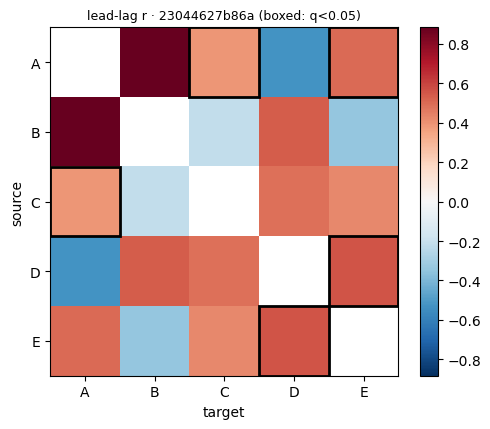

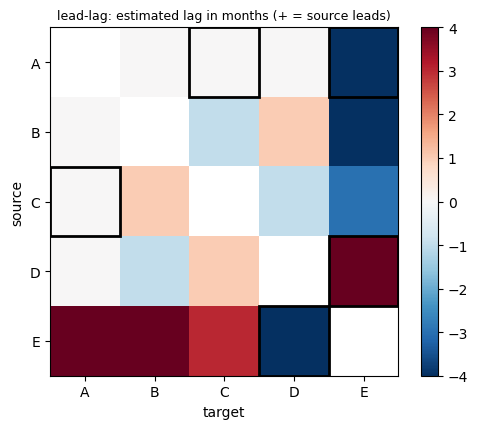

,target,statistic,lag,p_value,q_value
16,District_A,0.500096,4,0.080,0.17
17,District_B,-0.339475,4,1.000,1.00
18,District_C,0.423576,3,0.925,1.00
19,District_D,0.555234,-4,0.005,0.02


In [11]:
ll0 = PD.leadlag_matrix(run0)
PD.plot_matrix(ll0, "statistic", f"lead-lag r · {run0.world_id} (boxed: q<0.05)")
PD.plot_matrix(ll0, "lag", "lead-lag: estimated lag in months (+ = source leads)")
ll0[ll0.source.eq(run0.drift_district)][["target","statistic","lag","p_value","q_value"]]

## §D. Granger causality

Does adding the source's lags improve prediction of the target's next step **beyond the
target's own lags**? The own-lag baseline is what makes this directional — a model that
only checks whether the source predicts the target measures a shared driver.

Statistic is the in-sample proportional SSE reduction, deliberately: the null circularly
shifts the source, so surrogate models carry the same extra parameters and the same
optimism. `conditional=True` adds every other client's lags to both models, removing
transitive false positives (E→D→C appearing as E→C) at a steep cost in degrees of
freedom — watch `dof_ratio` and `underpowered`, which will refuse the fit outright at
`n_components=2, lags=2` on a 30-month world.

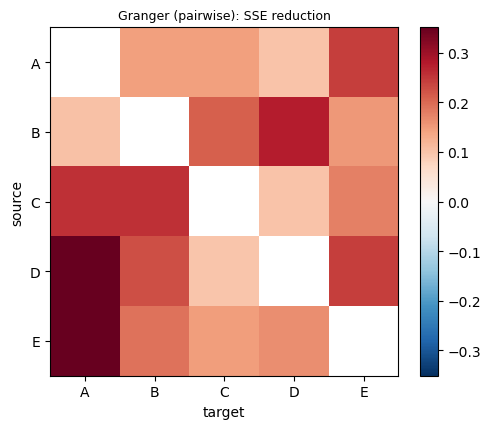

             statistic  n_obs  n_params  dof_ratio  underpowered
conditional                                                     
False            0.197   27.0       9.0      3.000           0.0
True               NaN   27.0      21.0      1.286           1.0


,source,target,statistic,p_value,dof_ratio
16,District_E,District_A,0.351199,0.01,3.0
12,District_D,District_A,0.350899,0.16,3.0
6,District_B,District_D,0.276968,0.26,3.0
8,District_C,District_A,0.256764,0.39,3.0
9,District_C,District_B,0.256079,0.34,3.0
3,District_A,District_E,0.243666,0.25,3.0
15,District_D,District_E,0.242144,0.18,3.0
13,District_D,District_B,0.225215,0.26,3.0


In [12]:
g0 = pd.concat([PD.granger_matrix(run0, conditional=False),
                PD.granger_matrix(run0, conditional=True)], ignore_index=True)
PD.plot_matrix(g0[~g0.conditional], "statistic", "Granger (pairwise): SSE reduction")
print(g0.groupby("conditional")[["statistic","n_obs","n_params","dof_ratio","underpowered"]]
        .mean(numeric_only=True).round(3).to_string())
g0[~g0.conditional].sort_values("statistic", ascending=False).head(8)[
    ["source","target","statistic","p_value","dof_ratio"]]

## §E. Predictive transfer

The original idea — *use the last few months of district A to predict B's next position*
— in its honest form: scored as the **increment** over a model using B's own last few
months, on a held-out tail. Raw accuracy would be high for every pair because prototypes
are autocorrelated and seasonally driven; only `delta_r2 > 0` says A carries information
about B that B does not already carry about itself.

Expect this to fail at 30 months: the test split is ~9 points against 4–8 parameters.
It is kept in because a negative result here is a real constraint on the design, not a
gap in the analysis.

In [13]:
pt0 = PD.predictive_transfer(run0)
print(f"mean own-history OOS R2 = {pt0.r2_own.mean():.3f} | mean delta_R2 = {pt0.statistic.mean():.3f} "
      f"| n_test = {pt0.n_test.iloc[0]}")
pt0.sort_values("statistic", ascending=False).head(8)[
    ["source","target","statistic","r2_own","p_value","q_value"]]

mean own-history OOS R2 = -0.161 | mean delta_R2 = -0.443 | n_test = 9


,source,target,statistic,r2_own,p_value,q_value
6,District_B,District_D,0.230823,-0.116866,0.41,0.880000
12,District_D,District_A,0.192102,-0.486472,0.82,1.000000
16,District_E,District_A,0.150464,-0.191005,0.77,1.000000
14,District_D,District_C,0.000759,-0.303090,1.00,1.000000
10,District_C,District_D,-0.010780,-0.405513,1.00,1.000000
8,District_C,District_A,-0.036608,-0.347850,0.97,1.000000
13,District_D,District_B,-0.041005,0.136659,0.96,1.000000
9,District_C,District_B,-0.078054,-0.105042,0.59,0.983333


## §F. Matched pairs — the quasi-interventional contrast

Runs sharing a consumption map and FL config but drifting a different district: same
demand structure, same hyperparameters, different intervention. A client that is not the
epicenter in either arm but still moves has moved because someone else did — dependence
measured against an external contrast rather than inferred from one series.

This is the closest thing to an ATE available in the existing cache. A true one needs
matched **drift-on / drift-off** worlds at the same seed, which has to be simulated;
`matched_displacement` takes them unchanged once they exist.

In [14]:
pairs = PD.matched_pairs(runs)
print(f"{len(pairs)} matched pairs")
if len(pairs):
    _run_cache = {}
    def _load(w, rid):
        if (w, rid) not in _run_cache:
            r = runs[(runs.world_id == w) & (runs.run_id == rid)].iloc[0]
            _run_cache[(w, rid)] = PD.ProtoRun(r["path"], w, rid, r["drift_district"],
                                            r["drift_onset"], cfg=CONFIG)
        return _run_cache[(w, rid)]

    md = PD.matched_displacement(pairs, _load)
    display(pairs[["consumption_map","world_a","world_b","drift_a","drift_b"]].drop_duplicates())
    display(md.groupby(["is_epicenter","spillover"])["displacement"]
              .agg(["mean","std","count"]).round(3))
else:
    md = pd.DataFrame()
    print("no matched pairs in the cache — simulate two worlds sharing a consumption map "
          "and FL config but drifting different districts")

1280 matched pairs


,consumption_map,world_a,world_b,drift_a,drift_b
0,LC_LR_LI_LR_LI,4e6c4526b7ca,4f816cfe3232,District_E,District_B
1,LC_LR_LI_LR_LI,4e6c4526b7ca,59bb964e8852,District_E,District_A
2,LC_LR_LI_LR_LI,4e6c4526b7ca,70fd6cfa961e,District_E,District_C
3,LC_LR_LI_LR_LI,4e6c4526b7ca,98d1539ce4a0,District_E,District_A
4,LC_LR_LI_LR_LI,4e6c4526b7ca,d4949f98c18f,District_E,District_D
...,...,...,...,...,...
995,LR_LI_LI_LC_LR,5aa9b868ccf1,eb97fb710b8f,District_C,District_A
996,LR_LI_LI_LC_LR,5aa9b868ccf1,ef803a0657e2,District_C,District_B
997,LR_LI_LI_LC_LR,5c6da4ac76fa,eb97fb710b8f,District_E,District_A
998,LR_LI_LI_LC_LR,5c6da4ac76fa,ef803a0657e2,District_E,District_B


mean    std  count
is_epicenter spillover                     
False        False      0.250  0.249   2560
             True       0.250  0.249   7680
True         False      0.652  0.443   2560

## 4. Full battery over every run, then the scoreboard

`top1_accuracy` is how often a method's highest-scoring source is the true drift
district, over all runs, against `chance = 1/n_clients`. `epicenter_lift` is the mean
statistic for pairs sourced at the epicenter minus the mean elsewhere — the more
sensitive read when no single pair clears significance.

Lead-lag is scored by net **leadership**, `mean(sign(lag) · |r|)`, not by `mean |r|`:
every client carries a delayed copy of the epicenter's bump, so `mean |r|` is high for
all of them and ranks the epicenter at chance.

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("once")
    tables = PD.analyse_all(runs, cfg=CONFIG, hops=HOPS)
print({k: v.shape for k, v in tables.items()})

  1044dfc21983 / 20260830-201447_fed_u30_r20_le1_a0.2_agg2h_w24_s6
  1044dfc21983 / 20260830-201629_fed_u30_r20_le1_a0.0_agg2h_w24_s6
  1044dfc21983 / 20260830-201812_fed_u30_r20_le1_a0.2_agg2h_w24_s6
  1044dfc21983 / 20260830-202006_fed_u30_r20_le1_a0.2_agg2h_w84_s12
  1044dfc21983 / 20260830-202334_fed_u30_r40_le1_a0.2_agg2h_w24_s6
  1044dfc21983 / 20260830-202441_fed_u8_r20_le1_a0.2_agg2h_w24_s6
  125bcc3f1cb5 / 20260830-202627_fed_u30_r20_le1_a0.2_agg2h_w24_s6
  125bcc3f1cb5 / 20260830-202808_fed_u30_r20_le1_a0.0_agg2h_w24_s6
  125bcc3f1cb5 / 20260830-202950_fed_u30_r20_le1_a0.2_agg2h_w24_s6
  125bcc3f1cb5 / 20260830-203146_fed_u30_r20_le1_a0.2_agg2h_w84_s12
  125bcc3f1cb5 / 20260830-203512_fed_u30_r40_le1_a0.2_agg2h_w24_s6
  125bcc3f1cb5 / 20260830-203615_fed_u8_r20_le1_a0.2_agg2h_w24_s6
  13da76aafb4d / 20260830-203759_fed_u30_r20_le1_a0.2_agg2h_w24_s6
  13da76aafb4d / 20260830-203942_fed_u30_r20_le1_a0.0_agg2h_w24_s6
  13da76aafb4d / 20260830-204129_fed_u30_r20_le1_a0.2_agg2h_w2

c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\proto_dependence.py:983: RuntimeWarning: Mean of empty slice
  epicenter_lift=float(np.nanmean(ep) - np.nanmean(other)),


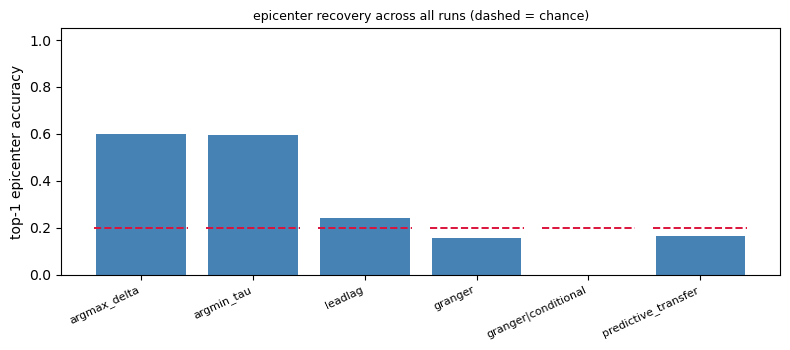

,module,method,n_runs,top1_accuracy,mean_rank_of_truth,n_runs_scored,chance,epicenter_lift,frac_significant,frac_underpowered
0,attribution,argmax_delta,240,0.600,1.600,240,0.2,NaN,NaN,NaN
1,attribution,argmin_tau,240,0.596,1.708,240,0.2,NaN,NaN,NaN
2,leadlag,leadlag,240,0.242,3.133,240,0.2,-0.106,0.056,NaN
3,granger,granger,240,0.158,3.258,240,0.2,-0.012,0.015,0.0
4,granger,granger|conditional,240,NaN,NaN,0,0.2,NaN,0.000,1.0
5,predictive_transfer,predictive_transfer,240,0.167,3.383,240,0.2,-0.121,0.007,NaN


In [16]:
sb = PD.scoreboard(tables, alpha=CONFIG["alpha"])
PD.plot_scoreboard(sb)
sb.round(3)

In [22]:
# joint-agreement subset: runs where BOTH onset estimators point at the same district
att = tables["attribution"].pivot(index=["world_id","run_id"], columns="estimator", values="guess")
agree = att["argmax_delta"].eq(att["argmin_tau"])
truth = tables["attribution"].drop_duplicates(["world_id","run_id"]).set_index(["world_id","run_id"])["truth"]
print(f"both agree: {agree.mean():.2f} of runs | when they agree, correct: "
      f"{(att['argmax_delta'][agree] == truth[agree]).mean():.2f}")

both agree: 0.38 of runs | when they agree, correct: 0.90


In [ ]:
import statsmodels.api as sm

on = tables["onsets"]

def top_gap(g):
    d = g["delta"].abs().sort_values(ascending=False).to_numpy()
    return d[0] - d[1] if len(d) > 1 else np.nan

gap = on.groupby(["world_id", "run_id"]).apply(top_gap).rename("delta_gap")
amax = tables["attribution"].query("estimator == 'argmax_delta'").set_index(["world_id", "run_id"])
merged = amax.join(gap)
merged["gap_q"] = pd.qcut(merged["delta_gap"], 4, labels=["Q1", "Q2", "Q3", "Q4(confident)"])
merged.groupby("gap_q")["hit"].agg(["mean", "count"])

X = sm.add_constant(merged["delta_gap"])
logit = sm.Logit(merged["hit"].astype(int), X).fit(disp=0)
print(logit.summary2().tables[1])   # coefficient, std err, p-value on delta_gap

              Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
const     -0.222242  0.189434 -1.173189  0.240720 -0.593525  0.149042
delta_gap  1.919911  0.471032  4.075967  0.000046  0.996705  2.843116


Text(0, 0.5, 'P(correct)')

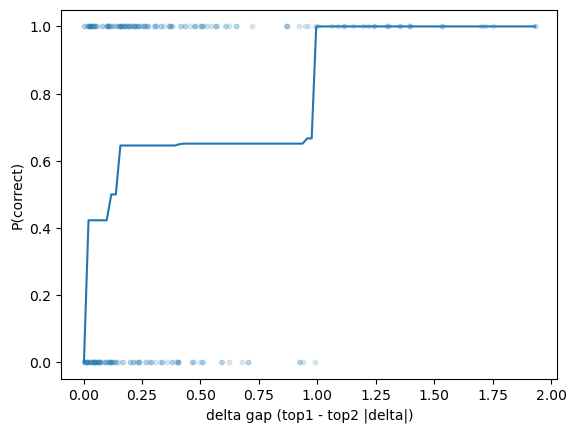

In [25]:
from sklearn.isotonic import IsotonicRegression
iso = IsotonicRegression(out_of_bounds="clip").fit(merged["delta_gap"], merged["hit"].astype(int))
xs = np.linspace(merged["delta_gap"].min(), merged["delta_gap"].max(), 100)
plt.plot(xs, iso.predict(xs)); plt.scatter(merged["delta_gap"], merged["hit"], alpha=.15, s=10)
plt.xlabel("delta gap (top1 - top2 |delta|)"); plt.ylabel("P(correct)")

In [17]:
# regime geometry pooled across runs: at N=5 no single run can clear alpha, so the
# question is whether the contrast is consistently positive
rg = tables["regime_geometry"]
rg[rg.test.eq("group_contrast") & rg.grouping.eq("sector")].groupby("round").agg(
    mean_statistic=("statistic","mean"), frac_positive=("statistic", lambda s: (s>0).mean()),
    min_p=("p_value","min"), p_floor=("p_floor","max"), n=("statistic","size")).round(3)

KeyError: 'regime_geometry'

In [18]:
# directional detail: does the epicenter lead, per run?
ll = tables["leadlag"]
ll.assign(lead=np.sign(ll.lag) * ll.statistic.abs()).groupby(
    ["world_id","source_is_epicenter"])["lead"].mean().unstack().round(3)

source_is_epicenter,False,True
world_id,,
1044dfc21983,-0.009,0.035
125bcc3f1cb5,-0.033,0.132
13da76aafb4d,0.032,-0.127
19fc3635df2e,0.012,-0.047
23044627b86a,-0.039,0.155
232cbaa03583,-0.004,0.015
2db9c177a153,0.023,-0.093
315e7ec909a4,-0.050,0.200
39552bbd95b0,0.022,-0.086


## 5. Stress grid

A method that finds the epicenter at one setting and loses it at the next is a
coincidence, not a finding. Each config re-runs modules B–E over every run, so cost is
`len(GRID) × len(runs)` — trim `n_surrogates` here rather than in `CONFIG`.

In [19]:
GRID = [
    dict(),                                    # CONFIG as-is
    dict(lags=1, n_components=1),              # the only setting where conditional GC fits
    dict(difference=False),                    # levels: ranks may improve, nulls are not valid
    dict(common_mode="mean"),                  # why the geometric median is the default
    dict(representation="dev_global_centered"),# FL-coupling control
]
sg = PD.stress_grid(runs, GRID, base={**CONFIG, "n_surrogates": 99,
                                      "n_surrogates_expensive": 49}, hops=HOPS)
sg.pivot_table(index="method", columns="config", values="top1_accuracy").round(2)

KeyboardInterrupt: 

In [ ]:
# a cell that is blank means every fit was refused for want of degrees of freedom
sg.pivot_table(index="method", columns="config", values="n_runs_scored")

## 6. Save

In [ ]:
written = PD.save_tables({**tables, "diagnostics": diag, "scoreboard": sb,
                          "stress_grid": sg, "matched_displacement": md}, OUT)
print("\n".join(str(p) for p in written))

## Notes carried out of the POC

* `argmax_delta` / `argmin_tau` are the load-bearing instruments — they reduce each
  client to one scalar per month and get an exact null out of the 5 districts. The
  regression modules are more expensive and much weaker at 30 months.
* `argmin_tau` collapses under `common_mode="mean"`: subtracting the cross-client mean
  injects −1/N of the epicenter's own drift into every other client, so everyone appears
  to change at the epicenter's onset and the ordering — the thing that carries the
  propagation delay — is destroyed. Hence the geometric median.
* Conditional Granger is not viable on a single 30-month world at
  `n_components=2, lags=2`; it needs `lags=1, n_components=1`, and even then reads at
  chance. Pooling runs or lengthening the horizon is the fix, not a smaller ridge.
* Two designs would identify more than one row of the influence matrix, and both are
  cheap because the simulator is ours: **staggered onsets** (drift E at month 10 and B
  at month 20 in the same world → staggered-adoption difference-in-differences, two
  identified rows plus a spillover estimate) and **matched drift-on / drift-off worlds**
  at the same seed, which turn §F into a real ATE per client.
* One open question that decides whether §D/§E mean anything: if per-month prototypes
  are compiled with any carry-over across months (EMA, cumulative), month *m* already
  contains month *m−1* for every client and cross-predictability is manufactured. The
  extraction path (a clean eval-mode pass per month) suggests not, worth confirming.